In [33]:
%pip install torch torchvision
%pip install fastai 


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [45]:
from fastai.vision.all import *
import matplotlib.pyplot as plt
import math

# **Download the dataset**

In [35]:
path = untar_data(URLs.PETS) / "images"

In [36]:
path

Path('/Users/sergiolopezortiz/.fastai/data/oxford-iiit-pet/images')

# **Prepare the data**

In [37]:
dls = ImageDataLoaders.from_name_func(
    path,
    get_image_files(path),
    valid_pct=0.2,
    seed=42,
    label_func=lambda x: x[0].isupper(),
    item_tfms=Resize(224)
)

In [44]:
i = 0
for file in get_image_files(path):
    print(file)
    i += 1
    if i >= 5:  # Print only the first 5 image files
        break


/Users/sergiolopezortiz/.fastai/data/oxford-iiit-pet/images/Egyptian_Mau_167.jpg
/Users/sergiolopezortiz/.fastai/data/oxford-iiit-pet/images/pug_52.jpg
/Users/sergiolopezortiz/.fastai/data/oxford-iiit-pet/images/basset_hound_112.jpg
/Users/sergiolopezortiz/.fastai/data/oxford-iiit-pet/images/Siamese_193.jpg
/Users/sergiolopezortiz/.fastai/data/oxford-iiit-pet/images/shiba_inu_122.jpg


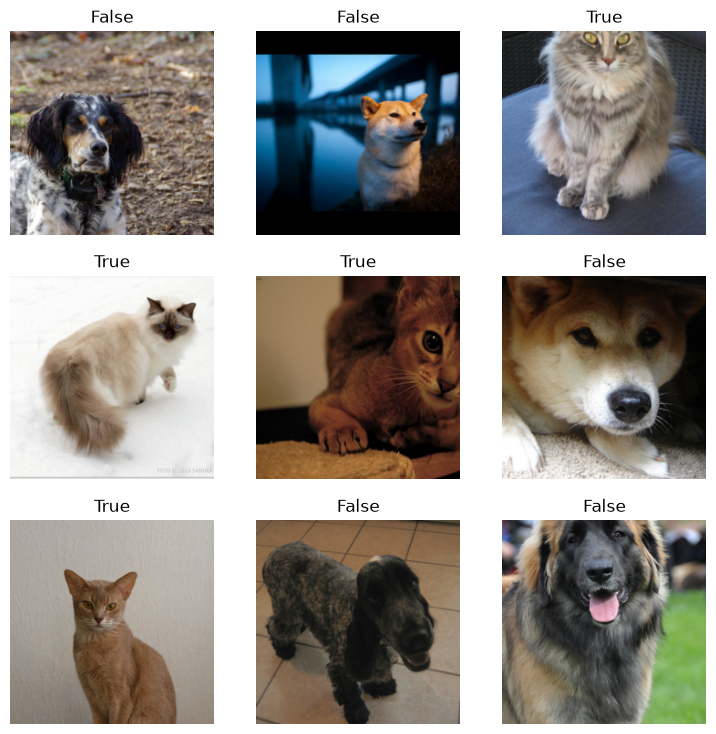

In [39]:
dls.show_batch(nrows=3, ncols=3)

# **Create the model**

In [40]:
learn = vision_learner(
    dls,
    resnet34, #NN Architecture
    metrics=error_rate
)

# **Train the model**

In [41]:
learn.fine_tune(1)

epoch,train_loss,valid_loss,error_rate,time
0,0.147949,0.027434,0.010149,00:55


epoch,train_loss,valid_loss,error_rate,time
0,0.062945,0.027738,0.008796,01:24


# **Make a prediction**

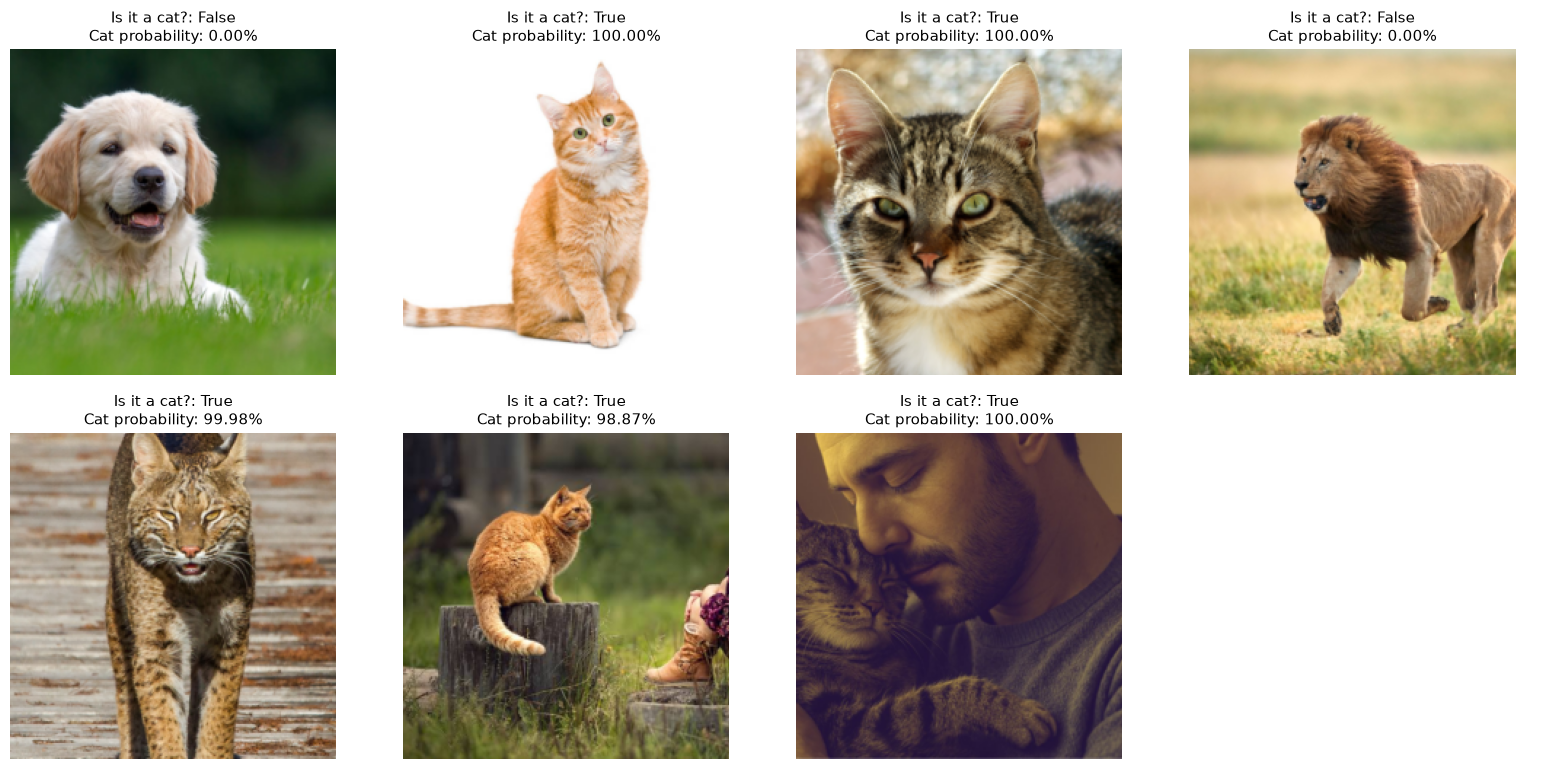

In [ ]:


images_array_test = [
    'dog2_test.jpg',
    'cat2_test.jpg',
    'cat1_test.jpg',
    'leon.jpg',
    'gato_montes.jpg',
    'gato_y_humano.jpeg',
    'gato_y_huamano_2.jpg'
]

cols = 4
rows = math.ceil(len(images_array_test) / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(16, 8)
)

axes = axes.flatten()

for i, image_path in enumerate(images_array_test):

    img = PILImage.create("test_data/" + image_path)

    # Resize image to 224x224
    img_resized = Resize(224)(img)

    is_cat, _, probs = learn.predict(img_resized)

    cat_probability = probs[1].item()
    not_cat_probability = probs[0].item()

    axes[i].imshow(img_resized)
    axes[i].axis('off')

    axes[i].set_title(
        f"Is it a cat?: {is_cat}\n"
        f"Cat probability: {cat_probability:.2%}",
        fontsize=11
    )

for i in range(len(images_array_test), len(axes)):
    axes[i].axis('off')

plt.tight_layout(pad=2)
plt.show()